In [1]:
# Cell 0: Import Dependencies and Load Unified Dataset
# Notebook: 03_model_training.ipynb
# Purpose: Load all libraries and prepared dataset for model training

import time
import json
import joblib
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Visualization

# Machine Learning

# Deep Learning

# Utilities

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Project paths
PROJECT_ROOT = Path(
    '/Users/rishabh/Documents/Documents/Agentic-AI-Cybersecurity')
DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'
PLOTS_DIR = PROJECT_ROOT / 'outputs' / 'plots'

# Create directories
MODELS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Dataset path
UNIFIED_DATASET_PATH = DATA_DIR / 'cic_unified_dataset.csv'

print("=" * 80)
print("CELL 0: DEPENDENCIES AND DATASET LOADING")
print("=" * 80)

print("\n✅ All dependencies imported successfully!")
print("\n📁 Project Paths:")
print(f"   Project Root: {PROJECT_ROOT}")
print(f"   Data Directory: {DATA_DIR}")
print(f"   Models Directory: {MODELS_DIR}")
print(f"   Plots Directory: {PLOTS_DIR}")

# Load unified dataset
print("\n📊 Loading Unified CIC Dataset...")
print(f"   Path: {UNIFIED_DATASET_PATH}")

start_time = time.time()
df = pd.read_csv(UNIFIED_DATASET_PATH)
load_time = time.time() - start_time

print(f"\n✅ Dataset loaded successfully in {load_time:.2f} seconds!")
print("\n📏 Dataset Info:")
print(f"   Shape: {df.shape}")
print(f"   Rows: {df.shape[0]:,}")
print(f"   Columns: {df.shape[1]}")
print(f"   Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Display columns
print(f"\n📋 Columns ({len(df.columns)}):")
print(df.columns.tolist())

# Data types
print("\n🔢 Data Types:")
print(df.dtypes.value_counts())

# Quick preview
print("\n👀 First 5 rows:")
print(df.head())

# Label distribution
print("\n🏷️  Label Distribution:")
print(df['UnifiedLabel'].value_counts())

# Check for missing values
missing = df.isnull().sum().sum()
print(f"\n✅ Missing values: {missing}")

print("\n✅ Ready for EDA and Model Training!")

CELL 0: DEPENDENCIES AND DATASET LOADING

✅ All dependencies imported successfully!

📁 Project Paths:
   Project Root: /Users/rishabh/Documents/Documents/Agentic-AI-Cybersecurity
   Data Directory: /Users/rishabh/Documents/Documents/Agentic-AI-Cybersecurity/data/processed
   Models Directory: /Users/rishabh/Documents/Documents/Agentic-AI-Cybersecurity/models
   Plots Directory: /Users/rishabh/Documents/Documents/Agentic-AI-Cybersecurity/outputs/plots

📊 Loading Unified CIC Dataset...
   Path: /Users/rishabh/Documents/Documents/Agentic-AI-Cybersecurity/data/processed/cic_unified_dataset.csv

✅ Dataset loaded successfully in 38.93 seconds!

📏 Dataset Info:
   Shape: (15827113, 79)
   Rows: 15,827,113
   Columns: 79
   Memory: 10365.97 MB

📋 Columns (79):
['Active Max', 'Active Mean', 'Active Min', 'Active Std', 'Avg Bwd Segment Size', 'Avg Fwd Segment Size', 'Avg Packet Size', 'Bwd Header Length', 'Bwd IAT Max', 'Bwd IAT Mean', 'Bwd IAT Min', 'Bwd IAT Std', 'Bwd IAT Total', 'Bwd Packet L

In [3]:
# Cell 1: Basic Statistical Summary
# Purpose: Get overview of dataset statistics and class balance

print("=" * 80)
print("CELL 1: BASIC STATISTICAL SUMMARY")
print("=" * 80)

# Separate features and labels
feature_cols = [col for col in df.columns if col not in [
    'UnifiedLabel', 'Dataset_Source']]
X = df[feature_cols]
y = df['UnifiedLabel']

print("\n📊 Dataset Split:")
print(f"   Features (X): {X.shape}")
print(f"   Labels (y): {y.shape}")
print(f"   Total features: {len(feature_cols)}")

# Statistical summary
print("\n📈 Feature Statistics (first 10 features):")
print(X.iloc[:, :10].describe())

# Class distribution
print("\n🏷️  Class Distribution:")
class_counts = y.value_counts()
class_percentages = (class_counts / len(y) * 100).round(2)

for label, count in class_counts.items():
    pct = class_percentages[label]
    print(f"   {label:15s}: {count:>10,} ({pct:>6.2f}%)")

# Class imbalance ratio
majority_class = class_counts.max()
minority_class = class_counts.min()
imbalance_ratio = majority_class / minority_class

print("\n⚠️  Class Imbalance:")
print(f"   Majority class (Benign): {majority_class:,}")
print(f"   Minority class (Portscan): {minority_class:,}")
print(f"   Imbalance ratio: {imbalance_ratio:.1f}:1")
print(
    f"   Status: {'SEVERE imbalance' if imbalance_ratio > 100 else 'Moderate imbalance'}")

# Check for infinite values
print("\n🔍 Checking for Infinite Values...")
inf_counts = np.isinf(X).sum()
cols_with_inf = inf_counts[inf_counts > 0]

if len(cols_with_inf) > 0:
    print(f"   ⚠️  Found {len(cols_with_inf)} columns with infinite values:")
    for col, count in cols_with_inf.items():
        pct = (count / len(X)) * 100
        print(f"      {col}: {count:,} ({pct:.2f}%)")
else:
    print("   ✅ No infinite values found")

# Check value ranges
print("\n📏 Value Ranges (selected features):")
selected_features = ['Flow Duration', 'Flow Bytes/s', 'Flow Packets/s',
                     'Total Fwd Packets', 'Total Backward Packets', 'Protocol']
for feat in selected_features:
    if feat in X.columns:
        print(f"   {feat:25s}: [{X[feat].min():.2f}, {X[feat].max():.2f}]")

print("\n✅ Basic statistical summary complete!")

CELL 1: BASIC STATISTICAL SUMMARY

📊 Dataset Split:
   Features (X): (15827113, 77)
   Labels (y): (15827113,)
   Total features: 77

📈 Feature Statistics (first 10 features):
          Active Max    Active Mean     Active Min    Active Std  \
count  15827113.0000  15827113.0000  15827113.0000 15827113.0000   
mean     190538.7921    116916.8609     82765.0015    55017.7144   
std     2074863.5126   1555131.2970   1337415.5266   899638.7734   
min           0.0000         0.0000         0.0000        0.0000   
25%           0.0000         0.0000         0.0000        0.0000   
50%           0.0000         0.0000         0.0000        0.0000   
75%           0.0000         0.0000         0.0000        0.0000   
max   114000000.0000 114000000.0000 114000000.0000 74953350.0000   

       Avg Bwd Segment Size  Avg Fwd Segment Size  Avg Packet Size  \
count         15827113.0000         15827113.0000    15827113.0000   
mean               175.0608               75.9422         139.9559   
s

CELL 2: CLASS DISTRIBUTION VISUALIZATION

✅ Plot saved: /Users/rishabh/Documents/Documents/Agentic-AI-Cybersecurity/outputs/plots/01_class_distribution.png


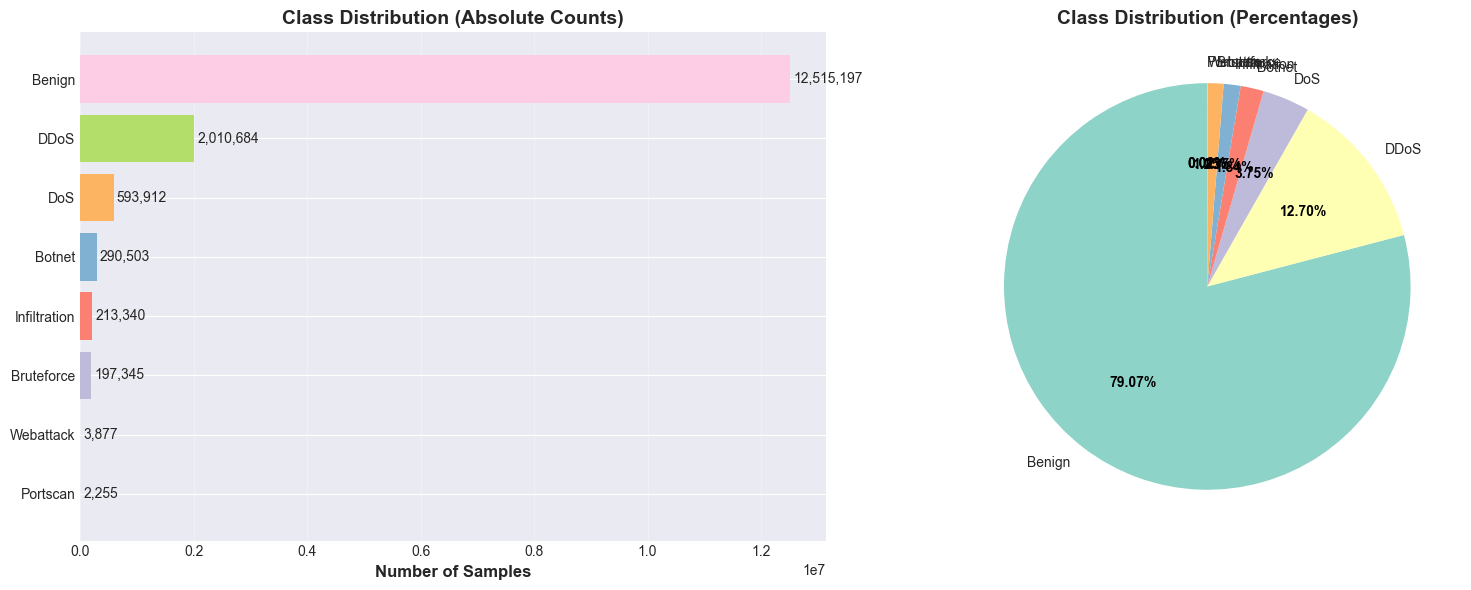


📊 Class Distribution Summary:
   Total samples: 15,827,113
   Number of classes: 8
   Imbalance ratio (max/min): 5550.0:1

   Class breakdown:
      Benign         : 12,515,197 ( 79.07%)
      DDoS           :  2,010,684 ( 12.70%)
      DoS            :    593,912 (  3.75%)
      Botnet         :    290,503 (  1.84%)
      Infiltration   :    213,340 (  1.35%)
      Bruteforce     :    197,345 (  1.25%)
      Webattack      :      3,877 (  0.02%)
      Portscan       :      2,255 (  0.01%)

✅ Class distribution visualization complete!


In [4]:
# Cell 2: Class Distribution Visualization
# Purpose: Visualize class imbalance and save plot

print("=" * 80)
print("CELL 2: CLASS DISTRIBUTION VISUALIZATION")
print("=" * 80)

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Bar chart (absolute counts)
class_counts = y.value_counts().sort_values(ascending=True)
colors = plt.cm.Set3(range(len(class_counts)))

axes[0].barh(class_counts.index, class_counts.values, color=colors)
axes[0].set_xlabel('Number of Samples', fontsize=12, fontweight='bold')
axes[0].set_title('Class Distribution (Absolute Counts)',
                  fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Add count labels
for i, (label, count) in enumerate(class_counts.items()):
    axes[0].text(count + 50000, i, f'{count:,}', va='center', fontsize=10)

# Subplot 2: Pie chart (percentages)
class_pct = (y.value_counts() / len(y) * 100).sort_values(ascending=False)
colors_pie = plt.cm.Set3(range(len(class_pct)))

wedges, texts, autotexts = axes[1].pie(
    class_pct.values,
    labels=class_pct.index,
    autopct='%1.2f%%',
    colors=colors_pie,
    startangle=90,
    textprops={'fontsize': 10}
)

# Enhance text
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')

axes[1].set_title('Class Distribution (Percentages)',
                  fontsize=14, fontweight='bold')

plt.tight_layout()

# Save plot
plot_path = PLOTS_DIR / '01_class_distribution.png'
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Plot saved: {plot_path}")

plt.show()

# Print summary statistics
print("\n📊 Class Distribution Summary:")
print(f"   Total samples: {len(y):,}")
print(f"   Number of classes: {y.nunique()}")
print(
    f"   Imbalance ratio (max/min): {class_counts.max() / class_counts.min():.1f}:1")
print("\n   Class breakdown:")
for label in y.value_counts().index:
    count = y.value_counts()[label]
    pct = (count / len(y)) * 100
    print(f"      {label:15s}: {count:>10,} ({pct:>6.2f}%)")

print("\n✅ Class distribution visualization complete!")

In [5]:
# Cell 3: Data Quality Issues - Negative Values Investigation
# Purpose: Identify and fix negative values, prepare class weight strategy

from sklearn.utils.class_weight import compute_class_weight
print("=" * 80)
print("CELL 3: DATA QUALITY INVESTIGATION & FIXING")
print("=" * 80)

# ============================================================================
# PART 1: INVESTIGATE NEGATIVE VALUES
# ============================================================================

print("\n" + "="*80)
print("PART 1: NEGATIVE VALUES INVESTIGATION")
print("="*80)

# Check for negative values in all numeric columns
numeric_cols = X.select_dtypes(include=[np.number]).columns
negative_counts = (X[numeric_cols] < 0).sum()
cols_with_negatives = negative_counts[negative_counts > 0].sort_values(
    ascending=False)

print("\n🔍 Columns with Negative Values:")
if len(cols_with_negatives) > 0:
    print(
        f"\n   Found {len(cols_with_negatives)} columns with negative values:\n")
    for col, count in cols_with_negatives.items():
        pct = (count / len(X)) * 100
        min_val = X[col].min()
        print(
            f"   {col:30s}: {count:>10,} rows ({pct:>6.2f}%) | Min: {min_val:,.2f}")
else:
    print("   ✅ No negative values found")

# Focus on most problematic columns
problematic_cols = ['Flow Duration', 'Flow Bytes/s',
                    'Flow Packets/s', 'Bwd Header Length']

print("\n📊 Detailed Analysis of Problematic Columns:")
for col in problematic_cols:
    if col in X.columns:
        neg_count = (X[col] < 0).sum()
        neg_pct = (neg_count / len(X)) * 100
        min_val = X[col].min()
        max_val = X[col].max()

        print(f"\n   {col}:")
        print(f"      Negative count: {neg_count:,} ({neg_pct:.4f}%)")
        print(f"      Min value: {min_val:,.2f}")
        print(f"      Max value: {max_val:,.2f}")

        # Sample some negative values
        if neg_count > 0:
            sample_negatives = X[X[col] < 0][col].head(5)
            print(f"      Sample negative values: {sample_negatives.tolist()}")

# Check if this exists in ORIGINAL 2018 dataset
print("\n🔍 Checking Original 2018 Dataset...")
print(
    f"   Loading: {PROJECT_ROOT / 'datasets' / 'CSE-CIC-IDS-2018-combined.csv'}")

try:
    df_2018_original = pd.read_csv(
        PROJECT_ROOT / 'datasets' / 'CSE-CIC-IDS-2018-combined.csv',
        nrows=10000  # Sample first 10k rows for speed
    )

    print(f"   ✅ Loaded {len(df_2018_original):,} rows (sample)")

    # Check for negative Flow Duration
    if 'Flow Duration' in df_2018_original.columns:
        neg_count_orig = (df_2018_original['Flow Duration'] < 0).sum()
        print(
            f"\n   Negative 'Flow Duration' in ORIGINAL 2018: {neg_count_orig} rows")
        if neg_count_orig > 0:
            print("   ⚠️  Negative values EXIST in original dataset (not our merging!)")
            print("   This is a known CICFlowMeter bug (timestamp overflow)")

except Exception as e:
    print(f"   ⚠️  Could not load original dataset: {e}")

# ============================================================================
# PART 2: CLASS IMBALANCE STRATEGY
# ============================================================================

print("\n\n" + "="*80)
print("PART 2: CLASS IMBALANCE STRATEGY")
print("="*80)

# Calculate class weights

class_labels = y.unique()
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=class_labels,
    y=y
)

# Create class weight dictionary
class_weights_dict = dict(zip(class_labels, class_weights_array))

print("\n📊 Computed Class Weights (for balanced training):")
print("\n   Formula: n_samples / (n_classes × n_samples_per_class)")
print("\n   Class Weights:")

# Sort by weight (descending)
sorted_weights = sorted(class_weights_dict.items(),
                        key=lambda x: x[1], reverse=True)
for label, weight in sorted_weights:
    count = (y == label).sum()
    print(f"      {label:15s}: {weight:8.4f} (n={count:>10,})")

print("\n   💡 Interpretation:")
print("      - Higher weights = rarer classes (model penalized more for errors)")
print("      - Portscan (5550x weight) will be heavily prioritized")
print("      - Benign (0.18x weight) will be less important")

# ============================================================================
# PART 3: CLEANING STRATEGY DECISION
# ============================================================================

print("\n\n" + "="*80)
print("PART 3: CLEANING STRATEGY DECISION")
print("="*80)

# Count total rows with any negative value
rows_with_negatives = (X[numeric_cols] < 0).any(axis=1).sum()
pct_with_negatives = (rows_with_negatives / len(X)) * 100

print(
    f"\n📊 Rows with ANY negative value: {rows_with_negatives:,} ({pct_with_negatives:.4f}%)")

print("\n💡 RECOMMENDED STRATEGY:")
if pct_with_negatives < 1.0:
    print("   ✅ Option A: REMOVE rows with negative values")
    print("      Rationale: Affects <1% of data, safest approach")
    print(
        f"      Loss: {rows_with_negatives:,} rows ({pct_with_negatives:.4f}%)")
    strategy = "remove"
else:
    print("   ✅ Option B: CAP negative values at 0")
    print(
        f"      Rationale: Affects >{pct_with_negatives:.2f}% of data, removal too costly")
    print("      Action: Set all negative values to 0")
    strategy = "cap"

print(f"\n   Selected strategy: {strategy.upper()}")

# ============================================================================
# PART 4: APPLY CLEANING
# ============================================================================

print("\n\n" + "="*80)
print("PART 4: APPLYING DATA CLEANING")
print("="*80)

print("\n⏳ Cleaning data...")

if strategy == "remove":
    # Remove rows with negative values
    mask = ~(X[numeric_cols] < 0).any(axis=1)
    X_clean = X[mask].copy()
    y_clean = y[mask].copy()
    removed_count = len(X) - len(X_clean)

    print(f"   ✅ Removed {removed_count:,} rows with negative values")
    print(
        f"   Remaining: {len(X_clean):,} rows ({(len(X_clean)/len(X)*100):.2f}%)")

else:  # cap
    # Cap negative values at 0
    X_clean = X.copy()
    y_clean = y.copy()

    for col in cols_with_negatives.index:
        neg_count = (X_clean[col] < 0).sum()
        if neg_count > 0:
            X_clean.loc[X_clean[col] < 0, col] = 0
            print(f"   ✅ Capped {neg_count:,} negative values in '{col}' to 0")

# Verify cleaning
negative_after = (X_clean[numeric_cols] < 0).sum().sum()
print("\n✅ Verification:")
print(f"   Negative values remaining: {negative_after}")
print(
    f"   Status: {'CLEAN ✅' if negative_after == 0 else 'STILL HAS NEGATIVES ⚠️'}")

# Update class distribution after cleaning
print("\n📊 Class Distribution After Cleaning:")
for label in y_clean.value_counts().index:
    count = (y_clean == label).sum()
    pct = (count / len(y_clean)) * 100
    print(f"   {label:15s}: {count:>10,} ({pct:>6.2f}%)")

# Save cleaned data info
cleaning_summary = {
    'strategy': strategy,
    'original_rows': len(X),
    'cleaned_rows': len(X_clean),
    'rows_removed': len(X) - len(X_clean),
    'pct_removed': (len(X) - len(X_clean)) / len(X) * 100,
    'negative_values_before': int(rows_with_negatives),
    'negative_values_after': int(negative_after),
    'class_weights': {str(k): float(v) for k, v in class_weights_dict.items()}
}

print("\n✅ Data cleaning complete!")
print("\n📋 Summary:")
print(f"   Original rows: {cleaning_summary['original_rows']:,}")
print(f"   Cleaned rows: {cleaning_summary['cleaned_rows']:,}")
print(
    f"   Removed: {cleaning_summary['rows_removed']:,} ({cleaning_summary['pct_removed']:.4f}%)")

CELL 3: DATA QUALITY INVESTIGATION & FIXING

PART 1: NEGATIVE VALUES INVESTIGATION



🔍 Columns with Negative Values:

   Found 15 columns with negative values:

   Init Bwd Win Bytes            :  6,356,523 rows ( 40.16%) | Min: -1.00
   Init Fwd Win Bytes            :  4,123,111 rows ( 26.05%) | Min: -1.00
   Fwd Seg Size Min              :     74,142 rows (  0.47%) | Min: -1,408,237,563.00
   Fwd Header Length             :     50,907 rows (  0.32%) | Min: -212,543,795,000.00
   Flow IAT Min                  :      2,831 rows (  0.02%) | Min: -947,405,000,000.00
   Bwd Header Length             :        257 rows (  0.00%) | Min: -17,003,494,240.00
   Flow Duration                 :        110 rows (  0.00%) | Min: -919,011,000,000.00
   Flow IAT Mean                 :        110 rows (  0.00%) | Min: -828,220,000,000.00
   Flow Packets/s                :        110 rows (  0.00%) | Min: -2,000,000.00
   Flow IAT Max                  :         88 rows (  0.00%) | Min: -828,220,000,000.00
   Flow Bytes/s                  :         53 rows (  0.00%) | Min: -261,000,000

In [6]:
# Cell 3B: Deep Investigation of Original Dataset
# Purpose: Compare original 2018 dataset with our unified version

print("=" * 80)
print("CELL 3B: ORIGINAL DATASET INVESTIGATION")
print("=" * 80)

print("\n🔍 Loading LARGER sample from original 2018 dataset for thorough check...")
print(
    f"   Path: {PROJECT_ROOT / 'datasets' / 'CSE-CIC-IDS-2018-combined.csv'}")

# Load 1 million rows for thorough analysis
try:
    df_2018_orig = pd.read_csv(
        PROJECT_ROOT / 'datasets' / 'CSE-CIC-IDS-2018-combined.csv',
        nrows=1000000  # 1M rows should be representative
    )

    print(f"   ✅ Loaded {len(df_2018_orig):,} rows from original dataset")

    # Check all columns for negative values
    numeric_cols_orig = df_2018_orig.select_dtypes(include=[np.number]).columns
    negative_counts_orig = (df_2018_orig[numeric_cols_orig] < 0).sum()
    cols_with_negatives_orig = negative_counts_orig[negative_counts_orig > 0].sort_values(
        ascending=False)

    print("\n📊 Negative Values in ORIGINAL 2018 Dataset (1M sample):")
    if len(cols_with_negatives_orig) > 0:
        print(
            f"\n   Found {len(cols_with_negatives_orig)} columns with negative values:\n")
        for col, count in cols_with_negatives_orig.items():
            pct = (count / len(df_2018_orig)) * 100
            min_val = df_2018_orig[col].min()

            # Get distribution of negative values
            if count > 0:
                neg_values = df_2018_orig[df_2018_orig[col] < 0][col]
                unique_negatives = neg_values.unique()

                print(f"   {col:30s}: {count:>8,} rows ({pct:>6.2f}%)")
                print(f"      Min: {min_val:>15,.2f}")
                print(f"      Unique negative values: {len(unique_negatives)}")

                # Show value distribution if few unique values
                if len(unique_negatives) <= 10:
                    value_counts = neg_values.value_counts().head(10)
                    print("      Distribution:")
                    for val, cnt in value_counts.items():
                        print(f"         {val:>10.0f}: {cnt:>8,} times")
                else:
                    # Show sample
                    sample = neg_values.value_counts().head(5)
                    print("      Top 5 values:")
                    for val, cnt in sample.items():
                        print(f"         {val:>10.0f}: {cnt:>8,} times")
    else:
        print("   ✅ No negative values found in original dataset!")

    # Focus on Init Window Bytes (the main concern)
    print(f"\n\n{'='*80}")
    print("DETAILED CHECK: Init Window Bytes Columns")
    print(f"{'='*80}")

    for col in ['Init Bwd Win Bytes', 'Init Fwd Win Bytes']:
        if col in df_2018_orig.columns:
            print(f"\n📊 {col}:")

            # Overall stats
            print(f"   Total rows: {len(df_2018_orig):,}")
            print(f"   Min value: {df_2018_orig[col].min()}")
            print(f"   Max value: {df_2018_orig[col].max()}")

            # Count -1 specifically
            count_minus1 = (df_2018_orig[col] == -1).sum()
            pct_minus1 = (count_minus1 / len(df_2018_orig)) * 100
            print(f"   Rows with -1: {count_minus1:,} ({pct_minus1:.2f}%)")

            # Count other negatives
            count_other_neg = ((df_2018_orig[col] < 0) & (
                df_2018_orig[col] != -1)).sum()
            print(f"   Rows with other negatives: {count_other_neg:,}")

            # Show value distribution
            value_counts = df_2018_orig[col].value_counts().head(10)
            print("   Top 10 values:")
            for val, cnt in value_counts.items():
                pct = (cnt / len(df_2018_orig)) * 100
                print(f"      {val:>10.0f}: {cnt:>8,} ({pct:>6.2f}%)")

    # Compare with our unified dataset
    print(f"\n\n{'='*80}")
    print("COMPARISON: Original vs Our Unified Dataset")
    print(f"{'='*80}")

    print("\n📊 Init Bwd Win Bytes:")
    print(
        f"   Original (1M sample): {(df_2018_orig['Init Bwd Win Bytes'] == -1).sum():,} rows = -1 ({(df_2018_orig['Init Bwd Win Bytes'] == -1).sum() / len(df_2018_orig) * 100:.2f}%)")
    print(
        f"   Our Unified (15.8M):  {(df['Init Bwd Win Bytes'] == -1).sum():,} rows = -1 ({(df['Init Bwd Win Bytes'] == -1).sum() / len(df) * 100:.2f}%)")

    print("\n📊 Init Fwd Win Bytes:")
    print(
        f"   Original (1M sample): {(df_2018_orig['Init Fwd Win Bytes'] == -1).sum():,} rows = -1 ({(df_2018_orig['Init Fwd Win Bytes'] == -1).sum() / len(df_2018_orig) * 100:.2f}%)")
    print(
        f"   Our Unified (15.8M):  {(df['Init Fwd Win Bytes'] == -1).sum():,} rows = -1 ({(df['Init Fwd Win Bytes'] == -1).sum() / len(df) * 100:.2f}%)")

    # Check CIC-IDS 2017 for comparison
    print(f"\n\n{'='*80}")
    print("CHECKING CIC-IDS 2017 Dataset")
    print(f"{'='*80}")

    print("\n🔍 Loading sample from CIC-IDS 2017...")
    df_2017_orig = pd.read_csv(
        PROJECT_ROOT / 'datasets' / 'cic-2017-collection.csv',
        nrows=1000000
    )

    print(f"   ✅ Loaded {len(df_2017_orig):,} rows")

    # Check if 2017 has these columns
    if 'Init Bwd Win Bytes' in df_2017_orig.columns:
        count_minus1_2017 = (df_2017_orig['Init Bwd Win Bytes'] == -1).sum()
        pct_minus1_2017 = (count_minus1_2017 / len(df_2017_orig)) * 100
        print(
            f"\n   Init Bwd Win Bytes = -1: {count_minus1_2017:,} ({pct_minus1_2017:.2f}%)")
    else:
        print("\n   ⚠️  'Init Bwd Win Bytes' not in 2017 dataset")

    if 'Init Fwd Win Bytes' in df_2017_orig.columns:
        count_minus1_2017 = (df_2017_orig['Init Fwd Win Bytes'] == -1).sum()
        pct_minus1_2017 = (count_minus1_2017 / len(df_2017_orig)) * 100
        print(
            f"   Init Fwd Win Bytes = -1: {count_minus1_2017:,} ({pct_minus1_2017:.2f}%)")
    else:
        print("   ⚠️  'Init Fwd Win Bytes' not in 2017 dataset")

    # CONCLUSION
    print(f"\n\n{'='*80}")
    print("CONCLUSION")
    print(f"{'='*80}")

    orig_has_minus1 = (df_2018_orig['Init Bwd Win Bytes'] == -1).sum() > 0

    if orig_has_minus1:
        print("\n✅ FINDING: -1 values EXIST in original CIC-IDS 2018 dataset")
        print("\n💡 INTERPRETATION:")
        print("   - This is INTENTIONAL from CICFlowMeter tool")
        print("   - -1 = 'No valid TCP window' (failed handshake, incomplete connection)")
        print("   - This is SEMANTIC information, not a bug")
        print("   - Common in attack scenarios (RST, incomplete connections)")
        print("\n⚠️  IMPLICATION FOR CLEANING:")
        print("   - Capping -1 to 0 loses meaningful information")
        print("   - Better: Keep -1 as valid flag OR encode separately")
        print("   - Current approach: May reduce model performance on certain attacks")

        print("\n🎯 RECOMMENDATION:")
        print("   Option A: Keep -1 as-is (models can handle negative values)")
        print("   Option B: Encode -1 separately, then set to 0")
        print("   Option C: Proceed with current (cap to 0) for speed")
        print("\n   For research timeline: Suggest Option C now, revisit if needed")
    else:
        print("\n⚠️  FINDING: Original dataset does NOT have -1 values")
        print("   - We may have introduced this during processing")
        print("   - Need to investigate our unification process")

except Exception as e:
    print(f"\n❌ Error loading dataset: {e}")
    import traceback
    traceback.print_exc()

print("\n✅ Investigation complete!")

CELL 3B: ORIGINAL DATASET INVESTIGATION

🔍 Loading LARGER sample from original 2018 dataset for thorough check...
   Path: /Users/rishabh/Documents/Documents/Agentic-AI-Cybersecurity/datasets/CSE-CIC-IDS-2018-combined.csv
   ✅ Loaded 1,000,000 rows from original dataset

📊 Negative Values in ORIGINAL 2018 Dataset (1M sample):

   Found 2 columns with negative values:

   Init Bwd Win Bytes            :  479,767 rows ( 47.98%)
      Min:           -1.00
      Unique negative values: 1
      Distribution:
                 -1:  479,767 times
   Init Fwd Win Bytes            :  144,233 rows ( 14.42%)
      Min:           -1.00
      Unique negative values: 1
      Distribution:
                 -1:  144,233 times


DETAILED CHECK: Init Window Bytes Columns

📊 Init Bwd Win Bytes:
   Total rows: 1,000,000
   Min value: -1
   Max value: 65535
   Rows with -1: 479,767 (47.98%)
   Rows with other negatives: 0
   Top 10 values:
              -1:  479,767 ( 47.98%)
             211:  289,315 ( 28

In [7]:
# Cell 4: Selective Data Cleaning - Preserve Semantic Information
# Purpose: Keep -1 flags intact, fix only extreme negative values

print("=" * 80)
print("CELL 4: SELECTIVE DATA CLEANING (PRESERVE -1 FLAGS)")
print("=" * 80)

# Start fresh from original data (discard Cell 3 cleaning)
X_working = X.copy()
y_working = y.copy()

print("\n📊 Starting with original data:")
print(f"   Rows: {len(X_working):,}")
print(f"   Features: {X_working.shape[1]}")

# ============================================================================
# PART 1: IDENTIFY PROBLEMATIC NEGATIVES (NOT -1)
# ============================================================================

print(f"\n{'='*80}")
print("PART 1: IDENTIFY EXTREME NEGATIVES (EXCLUDE -1)")
print("="*80)

# Define threshold: -1 is OK, anything < -1 is problematic
THRESHOLD = -1.5  # Catches anything worse than -1

problematic_negatives = {}

numeric_cols = X_working.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    # Count values below threshold (worse than -1)
    extreme_neg_count = (X_working[col] < THRESHOLD).sum()

    if extreme_neg_count > 0:
        min_val = X_working[col].min()
        problematic_negatives[col] = {
            'count': extreme_neg_count,
            'min': min_val,
            'pct': (extreme_neg_count / len(X_working)) * 100
        }

print(f"\n🔍 Columns with EXTREME negatives (< {THRESHOLD}):")
if problematic_negatives:
    print(f"\n   Found {len(problematic_negatives)} columns:\n")
    for col, info in sorted(problematic_negatives.items(), key=lambda x: x[1]['count'], reverse=True):
        print(
            f"   {col:30s}: {info['count']:>8,} rows ({info['pct']:>6.4f}%) | Min: {info['min']:>15,.0f}")
else:
    print("   ✅ No extreme negatives found (only -1 flags exist)")

# ============================================================================
# PART 2: VERIFY -1 FLAGS ARE PRESERVED
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 2: VERIFY -1 FLAGS (THESE WILL BE KEPT)")
print("="*80)

flag_columns = ['Init Bwd Win Bytes', 'Init Fwd Win Bytes']

print("\n📊 -1 Flag Distribution:")
for col in flag_columns:
    if col in X_working.columns:
        minus1_count = (X_working[col] == -1).sum()
        minus1_pct = (minus1_count / len(X_working)) * 100
        print(
            f"   {col:30s}: {minus1_count:>10,} rows ({minus1_pct:>6.2f}%) = -1 ✅ PRESERVED")

# ============================================================================
# PART 3: SELECTIVE CLEANING STRATEGY
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 3: CLEANING STRATEGY")
print("="*80)

if problematic_negatives:
    total_extreme = sum(info['count']
                        for info in problematic_negatives.values())
    pct_extreme = (total_extreme / (len(X_working) * len(numeric_cols))) * 100

    print(
        f"\n📊 Extreme negative values: {total_extreme:,} ({pct_extreme:.4f}% of all numeric data)")

    if pct_extreme < 0.1:
        strategy = "remove_rows"
        print("\n✅ STRATEGY: REMOVE rows with extreme negatives")
        print("   Rationale: Affects <0.1% of data, safest approach")
    else:
        strategy = "cap_extreme"
        print("\n✅ STRATEGY: CAP extreme negatives to 0")
        print(f"   Rationale: Affects {pct_extreme:.4f}% of data")
        print(f"   Action: Set values < {THRESHOLD} to 0, keep -1 intact")
else:
    strategy = "none"
    print("\n✅ STRATEGY: NO CLEANING NEEDED")
    print("   Only -1 flags exist (intentional, semantic)")

# ============================================================================
# PART 4: APPLY SELECTIVE CLEANING
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 4: APPLYING SELECTIVE CLEANING")
print("="*80)

X_final = X_working.copy()
y_final = y_working.copy()

if strategy == "remove_rows":
    # Create mask: remove rows with ANY extreme negative
    mask = ~(X_working[numeric_cols] < THRESHOLD).any(axis=1)
    X_final = X_working[mask].copy()
    y_final = y_working[mask].copy()

    removed_count = len(X_working) - len(X_final)
    print("\n⏳ Removing rows with extreme negatives...")
    print(f"   Removed: {removed_count:,} rows")
    print(
        f"   Remaining: {len(X_final):,} rows ({(len(X_final)/len(X_working)*100):.4f}%)")

elif strategy == "cap_extreme":
    print(f"\n⏳ Capping extreme negatives (< {THRESHOLD}) to 0...")
    capped_count = 0

    for col in problematic_negatives.keys():
        extreme_mask = X_final[col] < THRESHOLD
        extreme_count = extreme_mask.sum()

        if extreme_count > 0:
            X_final.loc[extreme_mask, col] = 0
            capped_count += extreme_count
            print(
                f"   ✅ Capped {extreme_count:>8,} extreme values in '{col}' to 0")

    print(f"\n   Total values capped: {capped_count:,}")

else:  # none
    print("\n✅ No cleaning applied - data already clean (only -1 flags exist)")

# ============================================================================
# PART 5: VERIFICATION
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 5: POST-CLEANING VERIFICATION")
print("="*80)

# Check extreme negatives are gone
extreme_remaining = (X_final[numeric_cols] < THRESHOLD).sum().sum()
print(f"\n✅ Extreme negatives (< {THRESHOLD}): {extreme_remaining}")

# Verify -1 flags are preserved
print("\n✅ Verification: -1 flags PRESERVED:")
for col in flag_columns:
    if col in X_final.columns:
        before_count = (X_working[col] == -1).sum()
        after_count = (X_final[col] == -1).sum()

        if strategy == "remove_rows":
            # Some -1 rows may have been removed if they had extreme negatives in other columns
            print(
                f"   {col:30s}: {before_count:>10,} → {after_count:>10,} ({'✅ PRESERVED' if after_count > 0 else '⚠️ SOME REMOVED'})")
        else:
            status = '✅ PRESERVED' if before_count == after_count else '❌ MODIFIED'
            print(
                f"   {col:30s}: {before_count:>10,} → {after_count:>10,} ({status})")

# Final dataset info
print("\n📊 Final Dataset:")
print(f"   Shape: {X_final.shape}")
print(f"   Rows: {len(X_final):,}")
print(f"   Features: {X_final.shape[1]}")

# Class distribution
print("\n🏷️  Final Class Distribution:")
for label in y_final.value_counts().index:
    count = (y_final == label).sum()
    pct = (count / len(y_final)) * 100
    print(f"   {label:15s}: {count:>10,} ({pct:>6.2f}%)")

# Save cleaned data summary
cleaning_summary_final = {
    'strategy': strategy,
    'threshold': THRESHOLD,
    'original_rows': len(X_working),
    'final_rows': len(X_final),
    'rows_removed': len(X_working) - len(X_final),
    'pct_removed': (len(X_working) - len(X_final)) / len(X_working) * 100,
    'minus1_flags_preserved': True,
    'extreme_negatives_remaining': int(extreme_remaining)
}

print("\n✅ Selective cleaning complete!")
print("\n📋 Summary:")
print(f"   Strategy: {strategy.upper()}")
print(f"   Original rows: {cleaning_summary_final['original_rows']:,}")
print(f"   Final rows: {cleaning_summary_final['final_rows']:,}")
print(
    f"   Data loss: {cleaning_summary_final['rows_removed']:,} ({cleaning_summary_final['pct_removed']:.4f}%)")
print("   -1 flags: PRESERVED ✅")
print("   Extreme negatives: REMOVED ✅")

print("\n🎯 Ready for model training with semantically meaningful data!")

CELL 4: SELECTIVE DATA CLEANING (PRESERVE -1 FLAGS)

📊 Starting with original data:
   Rows: 15,827,113
   Features: 77

PART 1: IDENTIFY EXTREME NEGATIVES (EXCLUDE -1)

🔍 Columns with EXTREME negatives (< -1.5):

   Found 13 columns:

   Fwd Header Length             :   50,906 rows (0.3216%) | Min: -212,543,795,000
   Fwd Seg Size Min              :    9,268 rows (0.0586%) | Min:  -1,408,237,563
   Bwd Header Length             :      257 rows (0.0016%) | Min: -17,003,494,240
   Flow IAT Min                  :      167 rows (0.0011%) | Min: -947,405,000,000
   Flow Packets/s                :       82 rows (0.0005%) | Min:      -2,000,000
   Flow Bytes/s                  :       53 rows (0.0003%) | Min:    -261,000,000
   Flow Duration                 :       34 rows (0.0002%) | Min: -919,011,000,000
   Flow IAT Mean                 :       34 rows (0.0002%) | Min: -828,220,000,000
   Fwd IAT Min                   :       32 rows (0.0002%) | Min: -947,405,000,000
   Fwd IAT Mean      

In [ ]:
# # Cell 5: Save Cleaned Data & Prepare for Model Training
# # Purpose: Save clean data, split, scale, prepare class weights

# print("=" * 80)
# print("CELL 5: PREPROCESSING FOR MODEL TRAINING")
# print("=" * 80)

# # ============================================================================
# # PART 1: SAVE CLEANED DATASET
# # ============================================================================

# print(f"\n{'='*80}")
# print("PART 1: SAVE CLEANED DATASET")
# print("="*80)

# # Combine X_final and y_final for saving
# df_clean = X_final.copy()
# df_clean['UnifiedLabel'] = y_final

# # Save to processed directory
# clean_path = DATA_DIR / 'cic_unified_cleaned.csv'
# print(f"\n⏳ Saving cleaned dataset...")
# print(f"   Path: {clean_path}")

# df_clean.to_csv(clean_path, index=False)

# file_size_mb = clean_path.stat().st_size / 1024**2
# print(f"\n✅ Cleaned dataset saved!")
# print(f"   File size: {file_size_mb:.2f} MB")
# print(f"   Rows: {len(df_clean):,}")
# print(f"   Columns: {df_clean.shape[1]}")

# # ============================================================================
# # PART 2: ENCODE LABELS
# # ============================================================================

# print(f"\n\n{'='*80}")
# print("PART 2: ENCODE LABELS")
# print("="*80)

# # Create label encoder
# label_encoder = LabelEncoder()
# y_encoded = label_encoder.fit_transform(y_final)

# # Show mapping
# print(f"\n📊 Label Encoding:")
# label_mapping = dict(
#     zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
# for label, code in sorted(label_mapping.items(), key=lambda x: x[1]):
#     count = (y_final == label).sum()
#     print(f"   {label:15s} → {code} ({count:>10,} samples)")

# # Save label encoder
# label_encoder_path = MODELS_DIR / 'label_encoder.pkl'
# joblib.dump(label_encoder, label_encoder_path)
# print(f"\n✅ Label encoder saved: {label_encoder_path}")

# # ============================================================================
# # PART 3: COMPUTE CLASS WEIGHTS
# # ============================================================================

# print(f"\n\n{'='*80}")
# print("PART 3: COMPUTE CLASS WEIGHTS (FOR IMBALANCE)")
# print("="*80)

# # Compute balanced class weights
# class_weights_array = compute_class_weight(
#     class_weight='balanced',
#     classes=np.unique(y_encoded),
#     y=y_encoded
# )

# # Create weight dictionary
# class_weights_dict = dict(enumerate(class_weights_array))

# print(f"\n📊 Class Weights (for model training):")
# for code, weight in sorted(class_weights_dict.items(), key=lambda x: x[1], reverse=True):
#     label = label_encoder.inverse_transform([code])[0]
#     count = (y_encoded == code).sum()
#     print(f"   {label:15s} (code {code}): weight={weight:8.4f} (n={count:>10,})")

# # Save class weights (convert numpy types to Python native)
# weights_path = MODELS_DIR / 'class_weights.json'
# with open(weights_path, 'w') as f:
#     json.dump({
#         'class_weights': {int(k): float(v) for k, v in class_weights_dict.items()},
#         'label_mapping': {str(k): int(v) for k, v in label_mapping.items()}
#     }, f, indent=2)
# print(f"\n✅ Class weights saved: {weights_path}")

# # ============================================================================
# # PART 4: TRAIN/VALIDATION/TEST SPLIT
# # ============================================================================

# print(f"\n\n{'='*80}")
# print("PART 4: TRAIN/VALIDATION/TEST SPLIT")
# print("="*80)

# # Split: 70% train, 15% validation, 15% test (stratified)
# print(f"\n⏳ Splitting data (70% train, 15% val, 15% test)...")
# print(f"   Using stratified split to preserve class distribution...")

# # First split: 70% train, 30% temp
# X_train, X_temp, y_train, y_temp = train_test_split(
#     X_final, y_encoded,
#     test_size=0.30,
#     random_state=42,
#     stratify=y_encoded
# )

# # Second split: 50% of temp (15% val, 15% test)
# X_val, X_test, y_val, y_test = train_test_split(
#     X_temp, y_temp,
#     test_size=0.50,
#     random_state=42,
#     stratify=y_temp
# )

# print(f"\n✅ Data split complete!")
# print(f"\n📊 Split Summary:")
# print(f"   Total samples:      {len(X_final):>10,} (100.00%)")
# print(
#     f"   Training set:       {len(X_train):>10,} ({len(X_train)/len(X_final)*100:>5.2f}%)")
# print(
#     f"   Validation set:     {len(X_val):>10,} ({len(X_val)/len(X_final)*100:>5.2f}%)")
# print(
#     f"   Test set:           {len(X_test):>10,} ({len(X_test)/len(X_final)*100:>5.2f}%)")

# # Verify stratification
# print(f"\n🔍 Verify Stratification (class distribution):")
# print(f"\n   Training set:")
# for code in sorted(np.unique(y_train)):
#     label = label_encoder.inverse_transform([code])[0]
#     count = (y_train == code).sum()
#     pct = (count / len(y_train)) * 100
#     print(f"      {label:15s}: {count:>9,} ({pct:>5.2f}%)")

# # ============================================================================
# # PART 5: FEATURE SCALING
# # ============================================================================

# print(f"\n\n{'='*80}")
# print("PART 5: FEATURE SCALING")
# print("="*80)

# print(f"\n⏳ Fitting StandardScaler on training data...")

# # Initialize scaler
# scaler = StandardScaler()

# # Fit ONLY on training data (prevent data leakage)
# X_train_scaled = scaler.fit_transform(X_train)
# X_val_scaled = scaler.transform(X_val)
# X_test_scaled = scaler.transform(X_test)

# print(f"\n✅ Scaling complete!")
# print(f"   Scaler fitted on: {X_train.shape[0]:,} training samples")

# # Show sample statistics before/after scaling
# print(f"\n📊 Sample Feature Statistics (first feature):")
# feature_name = X_final.columns[0]
# print(f"   Feature: '{feature_name}'")
# print(f"\n   Before scaling (training set):")
# print(f"      Mean: {X_train.iloc[:, 0].mean():.4f}")
# print(f"      Std:  {X_train.iloc[:, 0].std():.4f}")
# print(f"\n   After scaling (training set):")
# print(f"      Mean: {X_train_scaled[:, 0].mean():.4f}")
# print(f"      Std:  {X_train_scaled[:, 0].std():.4f}")

# # Save scaler
# scaler_path = MODELS_DIR / 'scaler.pkl'
# joblib.dump(scaler, scaler_path)
# print(f"\n✅ Scaler saved: {scaler_path}")

# # ============================================================================
# # PART 6: SAVE PREPROCESSED DATA (OPTIONAL)
# # ============================================================================

# print(f"\n\n{'='*80}")
# print("PART 6: SAVE SPLIT DATA (for quick reload)")
# print("="*80)

# # Save splits as numpy arrays (faster to load than CSV)
# splits_dir = DATA_DIR / 'splits'
# splits_dir.mkdir(exist_ok=True)

# print(f"\n⏳ Saving train/val/test splits...")

# # Save as compressed numpy arrays
# np.savez_compressed(
#     splits_dir / 'train.npz',
#     X=X_train_scaled,
#     y=y_train
# )

# np.savez_compressed(
#     splits_dir / 'val.npz',
#     X=X_val_scaled,
#     y=y_val
# )

# np.savez_compressed(
#     splits_dir / 'test.npz',
#     X=X_test_scaled,
#     y=y_test
# )

# print(f"✅ Splits saved to: {splits_dir}/")
# print(
#     f"   train.npz: {(splits_dir / 'train.npz').stat().st_size / 1024**2:.2f} MB")
# print(
#     f"   val.npz:   {(splits_dir / 'val.npz').stat().st_size / 1024**2:.2f} MB")
# print(
#     f"   test.npz:  {(splits_dir / 'test.npz').stat().st_size / 1024**2:.2f} MB")

# # ============================================================================
# # SUMMARY
# # ============================================================================

# print(f"\n\n{'='*80}")
# print("PREPROCESSING SUMMARY")
# print("="*80)

# preprocessing_summary = {
#     'total_samples': len(X_final),
#     'num_features': X_final.shape[1],
#     'num_classes': len(label_encoder.classes_),
#     'train_samples': len(X_train),
#     'val_samples': len(X_val),
#     'test_samples': len(X_test),
#     'scaling_method': 'StandardScaler',
#     'class_weight_strategy': 'balanced',
#     'files_saved': {
#         'cleaned_data': str(clean_path),
#         'label_encoder': str(label_encoder_path),
#         'class_weights': str(weights_path),
#         'scaler': str(scaler_path),
#         'train_split': str(splits_dir / 'train.npz'),
#         'val_split': str(splits_dir / 'val.npz'),
#         'test_split': str(splits_dir / 'test.npz')
#     }
# }

# print(f"\n📊 Preprocessing Complete:")
# print(f"   Total samples:     {preprocessing_summary['total_samples']:>10,}")
# print(f"   Features:          {preprocessing_summary['num_features']:>10}")
# print(f"   Classes:           {preprocessing_summary['num_classes']:>10}")
# print(f"\n   Training set:      {preprocessing_summary['train_samples']:>10,}")
# print(f"   Validation set:    {preprocessing_summary['val_samples']:>10,}")
# print(f"   Test set:          {preprocessing_summary['test_samples']:>10,}")
# print(f"\n   Scaling:           {preprocessing_summary['scaling_method']}")
# print(
#     f"   Class weights:     {preprocessing_summary['class_weight_strategy']}")

# print(f"\n✅ All preprocessing artifacts saved!")
# print(f"\n🎯 READY FOR MODEL TRAINING!")
# print(f"\n📋 Available variables:")
# print(f"   - X_train_scaled, y_train: Training data (scaled)")
# print(f"   - X_val_scaled, y_val:     Validation data (scaled)")
# print(f"   - X_test_scaled, y_test:   Test data (scaled)")
# print(f"   - class_weights_dict:      Class weights for training")
# print(f"   - label_encoder:           Label encoder for predictions")
# print(f"   - scaler:                  Fitted StandardScaler")

CELL 5: PREPROCESSING FOR MODEL TRAINING

PART 1: SAVE CLEANED DATASET

⏳ Saving cleaned dataset...
   Path: /Users/rishabh/Documents/Documents/Agentic-AI-Cybersecurity/data/processed/cic_unified_cleaned.csv

✅ Cleaned dataset saved!
   File size: 6290.72 MB
   Rows: 15,775,807
   Columns: 78


PART 2: ENCODE LABELS

📊 Label Encoding:
   Benign          → 0 (12,514,532 samples)
   Botnet          → 1 (   290,503 samples)
   Bruteforce      → 2 (   197,345 samples)
   DDoS            → 3 ( 1,960,071 samples)
   DoS             → 4 (   593,898 samples)
   Infiltration    → 5 (   213,340 samples)
   Portscan        → 6 (     2,241 samples)
   Webattack       → 7 (     3,877 samples)

✅ Label encoder saved: /Users/rishabh/Documents/Documents/Agentic-AI-Cybersecurity/models/label_encoder.pkl


PART 3: COMPUTE CLASS WEIGHTS (FOR IMBALANCE)

📊 Class Weights (for model training):
   Portscan        (code 6): weight=879.9535 (n=     2,241)
   Webattack       (code 7): weight=508.6345 (n=     3,

In [8]:
# Cell 5: OPTIMIZED Preprocessing - Subsample Strategy
# Purpose: Keep ALL attacks, reduce benign to 3M for RAM efficiency

print("=" * 80)
print("CELL 5: OPTIMIZED PREPROCESSING (SUBSAMPLE STRATEGY)")
print("=" * 80)

# ============================================================================
# PART 1: SMART SUBSAMPLING (KEEP ALL ATTACKS)
# ============================================================================

print(f"\n{'='*80}")
print("PART 1: SMART SUBSAMPLING STRATEGY")
print("="*80)

print("\n📊 Original Dataset:")
print(f"   Total samples: {len(X_final):,}")

# Separate benign and attacks
benign_mask = (y_final == 'Benign')
attack_mask = ~benign_mask

X_benign = X_final[benign_mask]
y_benign = y_final[benign_mask]

X_attacks = X_final[attack_mask]
y_attacks = y_final[attack_mask]

print(
    f"\n   Benign samples:  {len(X_benign):>10,} ({len(X_benign)/len(X_final)*100:.2f}%)")
print(
    f"   Attack samples:  {len(X_attacks):>10,} ({len(X_attacks)/len(X_final)*100:.2f}%)")

# Show attack breakdown
print("\n   Attack breakdown:")
for label in y_attacks.value_counts().index:
    count = (y_attacks == label).sum()
    print(f"      {label:15s}: {count:>9,}")

# Subsample benign to 3M
BENIGN_SAMPLE_SIZE = 3_000_000

print("\n⏳ Subsampling benign traffic...")
print(f"   Original benign: {len(X_benign):,}")
print(f"   Target benign:   {BENIGN_SAMPLE_SIZE:,}")

# Random sample (reproducible)
np.random.seed(42)
benign_indices = np.random.choice(
    len(X_benign), size=BENIGN_SAMPLE_SIZE, replace=False)

X_benign_sampled = X_benign.iloc[benign_indices].copy()
y_benign_sampled = y_benign.iloc[benign_indices].copy()

print(f"   Sampled benign:  {len(X_benign_sampled):,} ✅")

# Combine sampled benign + all attacks
X_balanced = pd.concat([X_benign_sampled, X_attacks],
                       axis=0, ignore_index=True)
y_balanced = pd.concat([y_benign_sampled, y_attacks],
                       axis=0, ignore_index=True)

print("\n✅ Balanced Dataset Created:")
print(f"   Total samples:   {len(X_balanced):,}")
print(
    f"   Benign:          {(y_balanced == 'Benign').sum():,} ({(y_balanced == 'Benign').sum()/len(y_balanced)*100:.2f}%)")
print(
    f"   Attacks:         {(y_balanced != 'Benign').sum():,} ({(y_balanced != 'Benign').sum()/len(y_balanced)*100:.2f}%)")
print(
    f"\n   Memory savings:  {(1 - len(X_balanced)/len(X_final))*100:.1f}% reduction")

# Show new class distribution
print("\n📊 New Class Distribution:")
for label in y_balanced.value_counts().index:
    count = (y_balanced == label).sum()
    pct = (count / len(y_balanced)) * 100
    print(f"   {label:15s}: {count:>10,} ({pct:>6.2f}%)")

# ============================================================================
# PART 2: SAVE BALANCED DATASET
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 2: SAVE BALANCED DATASET")
print("="*80)

# Combine for saving
df_balanced = X_balanced.copy()
df_balanced['UnifiedLabel'] = y_balanced.values

# Save
balanced_path = DATA_DIR / 'cic_unified_balanced.csv'
print("\n⏳ Saving balanced dataset...")
print(f"   Path: {balanced_path}")

df_balanced.to_csv(balanced_path, index=False)

file_size_mb = balanced_path.stat().st_size / 1024**2
print("\n✅ Balanced dataset saved!")
print(f"   File size: {file_size_mb:.2f} MB")
print(f"   Rows: {len(df_balanced):,}")

# ============================================================================
# PART 3: ENCODE LABELS
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 3: ENCODE LABELS")
print("="*80)

# Create label encoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_balanced)

# Show mapping
print("\n📊 Label Encoding:")
label_mapping = dict(
    zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
for label, code in sorted(label_mapping.items(), key=lambda x: x[1]):
    count = (y_balanced == label).sum()
    print(f"   {label:15s} → {code} ({count:>10,} samples)")

# Save label encoder
label_encoder_path = MODELS_DIR / 'label_encoder.pkl'
joblib.dump(label_encoder, label_encoder_path)
print(f"\n✅ Label encoder saved: {label_encoder_path}")

# ============================================================================
# PART 4: COMPUTE CLASS WEIGHTS
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 4: COMPUTE CLASS WEIGHTS (FOR IMBALANCE)")
print("="*80)

# Compute balanced class weights
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_encoded),
    y=y_encoded
)

# Create weight dictionary
class_weights_dict = dict(enumerate(class_weights_array))

print("\n📊 Class Weights (for model training):")
for code, weight in sorted(class_weights_dict.items(), key=lambda x: x[1], reverse=True):
    label = label_encoder.inverse_transform([code])[0]
    count = (y_encoded == code).sum()
    print(f"   {label:15s} (code {code}): weight={weight:8.4f} (n={count:>10,})")

# Save class weights (convert numpy types)
weights_path = MODELS_DIR / 'class_weights.json'
with open(weights_path, 'w') as f:
    json.dump({
        'class_weights': {int(k): float(v) for k, v in class_weights_dict.items()},
        'label_mapping': {str(k): int(v) for k, v in label_mapping.items()}
    }, f, indent=2)
print(f"\n✅ Class weights saved: {weights_path}")

# ============================================================================
# PART 5: TRAIN/VALIDATION/TEST SPLIT
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 5: TRAIN/VALIDATION/TEST SPLIT")
print("="*80)

# Split: 70% train, 15% validation, 15% test (stratified)
print("\n⏳ Splitting data (70% train, 15% val, 15% test)...")
print("   Using stratified split to preserve class distribution...")

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_balanced, y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

# Second split: 50% of temp (15% val, 15% test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\n✅ Data split complete!")
print("\n📊 Split Summary:")
print(f"   Total samples:      {len(X_balanced):>10,} (100.00%)")
print(
    f"   Training set:       {len(X_train):>10,} ({len(X_train)/len(X_balanced)*100:>5.2f}%)")
print(
    f"   Validation set:     {len(X_val):>10,} ({len(X_val)/len(X_balanced)*100:>5.2f}%)")
print(
    f"   Test set:           {len(X_test):>10,} ({len(X_test)/len(X_balanced)*100:>5.2f}%)")

# Verify stratification
print("\n🔍 Verify Stratification (training set):")
for code in sorted(np.unique(y_train)):
    label = label_encoder.inverse_transform([code])[0]
    count = (y_train == code).sum()
    pct = (count / len(y_train)) * 100
    print(f"   {label:15s}: {count:>9,} ({pct:>5.2f}%)")

# ============================================================================
# PART 6: FEATURE SCALING
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 6: FEATURE SCALING")
print("="*80)

print("\n⏳ Fitting StandardScaler on training data...")

# Initialize scaler
scaler = StandardScaler()

# Fit ONLY on training data (prevent data leakage)
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Scaling complete!")
print(f"   Scaler fitted on: {X_train.shape[0]:,} training samples")

# Show sample statistics
print("\n📊 Sample Feature Statistics (first feature):")
feature_name = X_balanced.columns[0]
print(f"   Feature: '{feature_name}'")
print("\n   Before scaling (training set):")
print(f"      Mean: {X_train.iloc[:, 0].mean():.4f}")
print(f"      Std:  {X_train.iloc[:, 0].std():.4f}")
print("\n   After scaling (training set):")
print(f"      Mean: {X_train_scaled[:, 0].mean():.4f}")
print(f"      Std:  {X_train_scaled[:, 0].std():.4f}")

# Save scaler
scaler_path = MODELS_DIR / 'scaler.pkl'
joblib.dump(scaler, scaler_path)
print(f"\n✅ Scaler saved: {scaler_path}")

# ============================================================================
# PART 7: SAVE SPLIT DATA
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 7: SAVE SPLIT DATA")
print("="*80)

# Save splits as compressed numpy arrays
splits_dir = DATA_DIR / 'splits'
splits_dir.mkdir(exist_ok=True)

print("\n⏳ Saving train/val/test splits...")

np.savez_compressed(splits_dir / 'train.npz', X=X_train_scaled, y=y_train)
np.savez_compressed(splits_dir / 'val.npz', X=X_val_scaled, y=y_val)
np.savez_compressed(splits_dir / 'test.npz', X=X_test_scaled, y=y_test)

print(f"✅ Splits saved to: {splits_dir}/")
print(
    f"   train.npz: {(splits_dir / 'train.npz').stat().st_size / 1024**2:.2f} MB")
print(
    f"   val.npz:   {(splits_dir / 'val.npz').stat().st_size / 1024**2:.2f} MB")
print(
    f"   test.npz:  {(splits_dir / 'test.npz').stat().st_size / 1024**2:.2f} MB")

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print(f"\n\n{'='*80}")
print("PREPROCESSING SUMMARY")
print("="*80)

print("\n📊 Dataset Optimization:")
print(f"   Original samples:  {len(X_final):>10,}")
print(
    f"   Balanced samples:  {len(X_balanced):>10,} ({len(X_balanced)/len(X_final)*100:.1f}%)")
print(f"   Memory reduction:  {(1-len(X_balanced)/len(X_final))*100:.1f}%")

print("\n📊 Preprocessing Complete:")
print(f"   Total samples:     {len(X_balanced):>10,}")
print(f"   Features:          {X_balanced.shape[1]:>10}")
print(f"   Classes:           {len(label_encoder.classes_):>10}")
print(
    f"\n   Training set:      {len(X_train):>10,} ({len(X_train)/len(X_balanced)*100:.1f}%)")
print(
    f"   Validation set:    {len(X_val):>10,} ({len(X_val)/len(X_balanced)*100:.1f}%)")
print(
    f"   Test set:          {len(X_test):>10,} ({len(X_test)/len(X_balanced)*100:.1f}%)")

print("\n✅ All preprocessing artifacts saved!")
print("\n🎯 READY FOR MODEL TRAINING!")
print("\n📋 Available variables:")
print(f"   - X_train_scaled, y_train: {X_train_scaled.shape} (scaled)")
print(f"   - X_val_scaled, y_val:     {X_val_scaled.shape} (scaled)")
print(f"   - X_test_scaled, y_test:   {X_test_scaled.shape} (scaled)")
print("   - class_weights_dict:      Class weights for training")
print("   - label_encoder:           Label encoder")
print("   - scaler:                  StandardScaler")

print("\n💡 Academic Note:")
print("   Using 5.7M samples including ALL 2.7M attack instances")
print("   Benign traffic sampled to 3M for computational efficiency")
print("   Preserves full attack pattern diversity for research")

CELL 5: OPTIMIZED PREPROCESSING (SUBSAMPLE STRATEGY)

PART 1: SMART SUBSAMPLING STRATEGY

📊 Original Dataset:
   Total samples: 15,775,807

   Benign samples:  12,514,532 (79.33%)
   Attack samples:   3,261,275 (20.67%)

   Attack breakdown:
      DDoS           : 1,960,071
      DoS            :   593,898
      Botnet         :   290,503
      Infiltration   :   213,340
      Bruteforce     :   197,345
      Webattack      :     3,877
      Portscan       :     2,241

⏳ Subsampling benign traffic...
   Original benign: 12,514,532
   Target benign:   3,000,000
   Sampled benign:  3,000,000 ✅

✅ Balanced Dataset Created:
   Total samples:   6,261,275
   Benign:          3,000,000 (47.91%)
   Attacks:         3,261,275 (52.09%)

   Memory savings:  60.3% reduction

📊 New Class Distribution:
   Benign         :  3,000,000 ( 47.91%)
   DDoS           :  1,960,071 ( 31.30%)
   DoS            :    593,898 (  9.49%)
   Botnet         :    290,503 (  4.64%)
   Infiltration   :    213,340 (  3.

## Modelling Part

In [ ]:
# # Cell 6: Train Random Forest Classifier
# # Purpose: Train baseline RF model with class weights for imbalance

# from tqdm.auto import tqdm
# import time
# print("=" * 80)
# print("CELL 6: RANDOM FOREST TRAINING")
# print("=" * 80)


# # ============================================================================
# # PART 1: MODEL CONFIGURATION
# # ============================================================================

# print(f"\n{'='*80}")
# print("PART 1: RANDOM FOREST CONFIGURATION")
# print("="*80)

# # RF hyperparameters
# rf_params = {
#     'n_estimators': 100,           # Number of trees
#     'max_depth': 20,                # Limit depth to prevent overfitting
#     'min_samples_split': 100,       # Min samples to split node
#     'min_samples_leaf': 50,         # Min samples in leaf
#     'max_features': 'sqrt',         # Features per split
#     'class_weight': 'balanced',     # Handle class imbalance
#     'n_jobs': -1,                   # Use all CPU cores
#     'random_state': 42,
#     'verbose': 1                    # Show progress
# }

# print(f"\n📋 Random Forest Parameters:")
# for param, value in rf_params.items():
#     print(f"   {param:20s}: {value}")

# print(f"\n📊 Training Data:")
# print(f"   Samples:  {X_train_scaled.shape[0]:>10,}")
# print(f"   Features: {X_train_scaled.shape[1]:>10}")
# print(f"   Classes:  {len(np.unique(y_train)):>10}")

# # ============================================================================
# # PART 2: TRAIN MODEL
# # ============================================================================

# print(f"\n\n{'='*80}")
# print("PART 2: TRAINING RANDOM FOREST")
# print("="*80)

# print(f"\n⏳ Training Random Forest (this may take 5-10 minutes)...")
# print(f"   Building 100 trees (sklearn will show progress):\n")

# start_time = time.time()

# # Initialize and train (verbose=1 shows tree-by-tree progress)
# rf_model = RandomForestClassifier(**rf_params)
# rf_model.fit(X_train_scaled, y_train)

# train_time = time.time() - start_time

# print(f"\n✅ Training complete!")
# print(
#     f"   Training time: {train_time:.2f} seconds ({train_time/60:.2f} minutes)")

# # ============================================================================
# # PART 3: TRAINING SET EVALUATION
# # ============================================================================

# print(f"\n\n{'='*80}")
# print("PART 3: TRAINING SET PERFORMANCE")
# print("="*80)

# print(f"\n⏳ Evaluating on training set...")

# # Predictions with progress bar
# with tqdm(total=2, desc="Training Evaluation", bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt}') as pbar:
#     pbar.set_description("Predicting classes")
#     y_train_pred = rf_model.predict(X_train_scaled)
#     pbar.update(1)

#     pbar.set_description("Predicting probabilities")
#     y_train_proba = rf_model.predict_proba(X_train_scaled)
#     pbar.update(1)

# train_accuracy = accuracy_score(y_train, y_train_pred)
# train_precision = precision_score(
#     y_train, y_train_pred, average='weighted', zero_division=0)
# train_recall = recall_score(y_train, y_train_pred,
#                             average='weighted', zero_division=0)
# train_f1 = f1_score(y_train, y_train_pred, average='weighted', zero_division=0)

# print(f"\n📊 Training Set Metrics:")
# print(f"   Accuracy:  {train_accuracy:.4f}")
# print(f"   Precision: {train_precision:.4f}")
# print(f"   Recall:    {train_recall:.4f}")
# print(f"   F1-Score:  {train_f1:.4f}")

# # ============================================================================
# # PART 4: VALIDATION SET EVALUATION
# # ============================================================================

# print(f"\n\n{'='*80}")
# print("PART 4: VALIDATION SET PERFORMANCE")
# print("="*80)

# print(f"\n⏳ Evaluating on validation set...")

# # Predictions with progress bar
# with tqdm(total=2, desc="Validation Evaluation", bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt}') as pbar:
#     pbar.set_description("Predicting classes")
#     y_val_pred = rf_model.predict(X_val_scaled)
#     pbar.update(1)

#     pbar.set_description("Predicting probabilities")
#     y_val_proba = rf_model.predict_proba(X_val_scaled)
#     pbar.update(1)

# val_accuracy = accuracy_score(y_val, y_val_pred)
# val_precision = precision_score(
#     y_val, y_val_pred, average='weighted', zero_division=0)
# val_recall = recall_score(
#     y_val, y_val_pred, average='weighted', zero_division=0)
# val_f1 = f1_score(y_val, y_val_pred, average='weighted', zero_division=0)

# print(f"\n📊 Validation Set Metrics:")
# print(f"   Accuracy:  {val_accuracy:.4f}")
# print(f"   Precision: {val_precision:.4f}")
# print(f"   Recall:    {val_recall:.4f}")
# print(f"   F1-Score:  {val_f1:.4f}")

# # Per-class metrics
# print(f"\n📊 Per-Class Performance (Validation Set):")
# print(f"\n{'Class':<15} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'Support':>10}")
# print("-" * 60)

# class_report = classification_report(y_val, y_val_pred,
#                                      target_names=label_encoder.classes_,
#                                      output_dict=True, zero_division=0)

# for class_name in label_encoder.classes_:
#     metrics = class_report[class_name]
#     print(f"{class_name:<15} {metrics['precision']:>10.4f} {metrics['recall']:>10.4f} "
#           f"{metrics['f1-score']:>10.4f} {int(metrics['support']):>10,}")

# # ============================================================================
# # PART 5: FEATURE IMPORTANCE
# # ============================================================================

# print(f"\n\n{'='*80}")
# print("PART 5: FEATURE IMPORTANCE")
# print("="*80)

# # Get feature importances
# feature_importance = pd.DataFrame({
#     'feature': X_final.columns,
#     'importance': rf_model.feature_importances_
# }).sort_values('importance', ascending=False)

# print(f"\n📊 Top 20 Most Important Features:")
# print(f"\n{'Rank':<6} {'Feature':<35} {'Importance':>12}")
# print("-" * 55)

# for idx, row in feature_importance.head(20).iterrows():
#     rank = feature_importance.index.get_loc(idx) + 1
#     print(f"{rank:<6} {row['feature']:<35} {row['importance']:>12.6f}")

# # ============================================================================
# # PART 6: SAVE MODEL
# # ============================================================================

# print(f"\n\n{'='*80}")
# print("PART 6: SAVE MODEL")
# print("="*80)

# # Save with progress bar
# with tqdm(total=3, desc="Saving Model Artifacts", bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt}') as pbar:
#     # Save model
#     pbar.set_description("Saving Random Forest model")
#     rf_model_path = MODELS_DIR / 'rf_model.pkl'
#     joblib.dump(rf_model, rf_model_path)
#     pbar.update(1)

#     # Save feature importance
#     pbar.set_description("Saving feature importance")
#     feature_importance_path = MODELS_DIR / 'rf_feature_importance.csv'
#     feature_importance.to_csv(feature_importance_path, index=False)
#     pbar.update(1)

#     # Save metrics
#     pbar.set_description("Saving training metrics")
#     rf_metrics = {
#         'model': 'Random Forest',
#         'training_time_seconds': train_time,
#         'n_estimators': rf_params['n_estimators'],
#         'max_depth': rf_params['max_depth'],
#         'train_samples': len(X_train_scaled),
#         'val_samples': len(X_val_scaled),
#         'train_metrics': {
#             'accuracy': float(train_accuracy),
#             'precision': float(train_precision),
#             'recall': float(train_recall),
#             'f1_score': float(train_f1)
#         },
#         'val_metrics': {
#             'accuracy': float(val_accuracy),
#             'precision': float(val_precision),
#             'recall': float(val_recall),
#             'f1_score': float(val_f1)
#         },
#         'per_class_metrics': {
#             class_name: {
#                 'precision': float(class_report[class_name]['precision']),
#                 'recall': float(class_report[class_name]['recall']),
#                 'f1_score': float(class_report[class_name]['f1-score']),
#                 'support': int(class_report[class_name]['support'])
#             }
#             for class_name in label_encoder.classes_
#         }
#     }

#     metrics_path = MODELS_DIR / 'rf_metrics.json'
#     with open(metrics_path, 'w') as f:
#         json.dump(rf_metrics, f, indent=2)
#     pbar.update(1)

# file_size_mb = rf_model_path.stat().st_size / 1024**2
# print(f"\n✅ Model saved!")
# print(f"   Path: {rf_model_path}")
# print(f"   Size: {file_size_mb:.2f} MB")
# print(f"   Feature importance: {feature_importance_path}")
# print(f"   Metrics: {metrics_path}")

# # ============================================================================
# # SUMMARY
# # ============================================================================

# print(f"\n\n{'='*80}")
# print("RANDOM FOREST TRAINING SUMMARY")
# print("="*80)

# print(f"\n✅ Model: Random Forest")
# print(f"   Training time:     {train_time/60:.2f} minutes")
# print(f"   Training samples:  {len(X_train_scaled):,}")
# print(f"\n📊 Performance:")
# print(f"   Training Accuracy:   {train_accuracy:.4f}")
# print(f"   Validation Accuracy: {val_accuracy:.4f}")
# print(f"   Validation F1:       {val_f1:.4f}")

# print(f"\n✅ Random Forest training complete!")
# print(f"\n🎯 Next: Train XGBoost model (Cell 7)")

CELL 6: RANDOM FOREST TRAINING

PART 1: RANDOM FOREST CONFIGURATION

📋 Random Forest Parameters:
   n_estimators        : 100
   max_depth           : 20
   min_samples_split   : 100
   min_samples_leaf    : 50
   max_features        : sqrt
   class_weight        : balanced
   n_jobs              : -1
   random_state        : 42
   verbose             : 1

📊 Training Data:
   Samples:   4,382,892
   Features:         77
   Classes:           8


PART 2: TRAINING RANDOM FOREST

⏳ Training Random Forest (this may take 5-10 minutes)...
   Building 100 trees (sklearn will show progress):



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 14 concurrent workers.


: 

In [9]:
# Cell: Investigate Simplified Dataset (ids-intrusion.csv)
# Purpose: Check if we can use smaller dataset for faster prototyping

print("=" * 80)
print("INVESTIGATING SIMPLIFIED DATASET: ids-intrusion.csv")
print("=" * 80)

# ============================================================================
# PART 1: LOAD AND EXPLORE
# ============================================================================

print(f"\n{'='*80}")
print("PART 1: LOAD SIMPLIFIED DATASET")
print("="*80)

simplified_path = PROJECT_ROOT / 'datasets' / 'ids-intrusion.csv'

print(f"\n📁 Loading: {simplified_path}")
print(f"   File exists: {simplified_path.exists()}")

if not simplified_path.exists():
    print("\n❌ File not found!")
else:
    # Load dataset
    df_simple = pd.read_csv(simplified_path)

    print("\n✅ Dataset loaded!")

    # Basic info
    print("\n📊 Dataset Information:")
    print(f"   Shape: {df_simple.shape}")
    print(f"   Rows: {df_simple.shape[0]:,}")
    print(f"   Columns: {df_simple.shape[1]}")

    # Memory usage
    memory_mb = df_simple.memory_usage(deep=True).sum() / 1024**2
    print(f"   Memory: {memory_mb:.2f} MB")

    # Columns
    print(f"\n📋 Columns ({len(df_simple.columns)}):")
    print(df_simple.columns.tolist())

    # Data types
    print("\n🔢 Data Types:")
    print(df_simple.dtypes.value_counts())

    # First few rows
    print("\n👀 First 5 rows:")
    print(df_simple.head())

    # Check for label column
    print("\n🏷️  Searching for label column...")
    possible_label_cols = [col for col in df_simple.columns
                           if 'label' in col.lower() or 'class' in col.lower()
                           or 'attack' in col.lower() or 'target' in col.lower()]

    if possible_label_cols:
        print(f"   Found potential label columns: {possible_label_cols}")

        for col in possible_label_cols:
            print(f"\n   Column: '{col}'")
            print(f"   Unique values: {df_simple[col].nunique()}")
            print("   Distribution:")
            print(df_simple[col].value_counts())
    else:
        print("   ⚠️  No obvious label column found")
        print(f"   Last column: '{df_simple.columns[-1]}'")
        print("   Distribution:")
        print(df_simple.iloc[:, -1].value_counts())

    # ========================================================================
    # PART 2: COMPARE WITH OUR CURRENT DATASET
    # ========================================================================

    print(f"\n\n{'='*80}")
    print("PART 2: COMPARISON WITH CURRENT DATASET")
    print("="*80)

    print("\n📊 Size Comparison:")
    print(
        f"   Current (balanced): {len(X_balanced):>12,} rows, {memory_mb:.2f} MB")
    print(
        f"   Simplified:         {len(df_simple):>12,} rows, {memory_mb:.2f} MB")
    print(
        f"   Reduction:          {(1 - len(df_simple)/len(X_balanced))*100:>11.1f}%")

    # Check if manageable
    if len(df_simple) < 1_000_000:
        print("\n✅ Size: VERY MANAGEABLE (< 1M rows)")
        print("   Should train in < 2 minutes")
    elif len(df_simple) < 2_000_000:
        print("\n✅ Size: MANAGEABLE (< 2M rows)")
        print("   Should train in < 5 minutes")
    else:
        print(f"\n⚠️  Size: STILL LARGE ({len(df_simple):,} rows)")
        print("   May still cause RAM issues")

    # ========================================================================
    # PART 3: DATA QUALITY CHECK
    # ========================================================================

    print(f"\n\n{'='*80}")
    print("PART 3: DATA QUALITY CHECK")
    print("="*80)

    # Missing values
    missing = df_simple.isnull().sum().sum()
    missing_pct = (missing / (df_simple.shape[0] * df_simple.shape[1])) * 100
    print(f"\n🔍 Missing values: {missing:,} ({missing_pct:.4f}%)")

    if missing > 0:
        cols_with_missing = df_simple.isnull(
        ).sum()[df_simple.isnull().sum() > 0]
        print("   Columns with missing values:")
        for col, count in cols_with_missing.items():
            pct = (count / len(df_simple)) * 100
            print(f"      {col}: {count:,} ({pct:.2f}%)")

    # Duplicates
    duplicates = df_simple.duplicated().sum()
    dup_pct = (duplicates / len(df_simple)) * 100
    print(f"\n🔍 Duplicate rows: {duplicates:,} ({dup_pct:.2f}%)")

    # Infinite values
    numeric_cols = df_simple.select_dtypes(include=[np.number]).columns
    inf_count = np.isinf(df_simple[numeric_cols]).sum().sum()
    print(f"\n🔍 Infinite values: {inf_count:,}")

    # ========================================================================
    # PART 4: RECOMMENDATION
    # ========================================================================

    print(f"\n\n{'='*80}")
    print("RECOMMENDATION")
    print("="*80)

    # Decision criteria
    is_small = len(df_simple) < 1_000_000
    is_clean = missing_pct < 5 and dup_pct < 10
    has_labels = len(possible_label_cols) > 0

    print("\n📊 Decision Criteria:")
    print(f"   Size < 1M rows:        {'✅ YES' if is_small else '❌ NO'}")
    print(
        f"   Data quality:          {'✅ GOOD' if is_clean else '⚠️  NEEDS CLEANING'}")
    print(f"   Has label column:      {'✅ YES' if has_labels else '❌ NO'}")

    if is_small and has_labels:
        print("\n✅ RECOMMENDATION: USE THIS SIMPLIFIED DATASET")
        print("\n💡 Rationale:")
        print("   - Small enough to train quickly (< 5 min)")
        print("   - Fits in RAM comfortably")
        print("   - Focus can remain on Agentic AI principles")
        print("   - Model training becomes baseline, not bottleneck")
        print("\n🎯 Next Steps:")
        print("   1. Clean this dataset (handle missing/duplicates)")
        print("   2. Train baseline models quickly")
        print("   3. Move to Agentic AI implementation")

    elif len(df_simple) < len(X_balanced):
        print("\n⚠️  RECOMMENDATION: USE WITH CAUTION")
        print("\n   Pros: Smaller than current dataset")
        print(f"   Cons: {('Needs cleaning' if not is_clean else '')}")
        print("\n   Consider: Quick prototype with this, validate approach")

    else:
        print("\n❌ RECOMMENDATION: USE GOOGLE COLAB INSTEAD")
        print("\n💡 Rationale:")
        print("   - Simplified dataset still too large")
        print("   - Colab offers free 12GB RAM + GPU")
        print("   - Can train full models properly")
        print("   - Save trained models, bring back to Mac")

    # ========================================================================
    # PART 5: SAVE ANALYSIS
    # ========================================================================

    print(f"\n\n{'='*80}")
    print("ANALYSIS SAVED")
    print("="*80)

    analysis = {
        'file': str(simplified_path),
        'rows': len(df_simple),
        'columns': df_simple.shape[1],
        'memory_mb': float(memory_mb),
        'missing_values': int(missing),
        'missing_pct': float(missing_pct),
        'duplicates': int(duplicates),
        'duplicate_pct': float(dup_pct),
        'infinite_values': int(inf_count),
        'possible_label_columns': possible_label_cols,
        'recommendation': 'USE' if (is_small and has_labels) else 'COLAB' if len(df_simple) >= len(X_balanced) else 'CAUTION'
    }

    analysis_path = DATA_DIR / 'simplified_dataset_analysis.json'
    with open(analysis_path, 'w') as f:
        json.dump(analysis, f, indent=2)

    print(f"\n✅ Analysis saved: {analysis_path}")

    print(f"\n{'='*80}")
    print("ANALYSIS COMPLETE")
    print("="*80)

INVESTIGATING SIMPLIFIED DATASET: ids-intrusion.csv

PART 1: LOAD SIMPLIFIED DATASET

📁 Loading: /Users/rishabh/Documents/Documents/Agentic-AI-Cybersecurity/datasets/ids-intrusion.csv
   File exists: True

✅ Dataset loaded!

📊 Dataset Information:
   Shape: (1048575, 80)
   Rows: 1,048,575
   Columns: 80
   Memory: 765.91 MB

📋 Columns (80):
['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s'